In [1]:
!pip install kagglehub
import kagglehub
import pandas as pd
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [ ]:
path = kagglehub.competition_download("digit-recognizer")
print("path to dataset:", path)

In [4]:
import matplotlib.pyplot as plt

df=pd.read_csv(f"{path}/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
import numpy as np

df=np.array(df)
m,n=df.shape
np.random.shuffle(df)

df_val=df[0:1000].T
y_val=df_val[0]
x_val=df_val[1:n]
x_val=x_val/255

df_train=df[1000:m].T
y_train=df_train[0]
x_train=df_train[1:n]
x_train=x_train/255
_,m_train=df_train.shape

In [6]:
print(x_train.shape)

(784, 41000)


In [7]:
def init_params():
  w1=np.random.rand(10,784)-0.5
  b1=np.random.rand(10,1)-0.5
  w2=np.random.rand(10,10)-0.5
  b2=np.random.rand(10,1)-0.5
  return w1,b1,w2,b2

def relu(z):
  return np.maximum(z,0)

def softmax(z):
  return np.exp(z)/sum(np.exp(z))

def forward_prop(x,w1,b1,w2,b2):
  z1=w1.dot(x)+b1
  A1=relu(z1)
  z2=w2.dot(A1)+b2
  A2=softmax(z2)
  return z1,A1,z2,A2

def relu_deriv(z):
  return z>0

def one_hot(y):
  one_hot_y=np.zeros((y.size,y.max()+1))
  one_hot_y[np.arange(y.size),y]=1
  one_hot_y=one_hot_y.T
  return one_hot_y

def back_prop(a1,a2,x,y,w1,z1,w2,z2):
  one_hot_y=one_hot(y)
  dz2=a2-one_hot_y
  dw2=1/m*dz2.dot(a1.T)
  db2=1/m*np.sum(dz2)
  dz1=w2.T.dot(dz2)*relu_deriv(z1)
  dw1=1/m*dz1.dot(x.T)
  db1=1/m*np.sum(dz1)
  return dw1,db1,dw2,db2

def update_params(w1,b1,w2,b2,dw1,db1,dw2,db2, alpha):
  w1-=alpha*dw1
  b1-=alpha*db1
  w2-=alpha*dw2
  b2-=alpha*db2
  return w1,b1,w2,b2

In [8]:
def get_pred(a2):
  return np.argmax(a2,0)

def get_accuracy(pred, y):
  print(pred,y)
  return np.sum(pred==y)/y.size

def gradient_descent(x,y,alpha,iter):
  w1,b1,w2,b2=init_params()
  for i in range(iter):
    z1,a1,z2,a2=forward_prop(x,w1,b1,w2,b2)
    dw1,db1,dw2,db2=back_prop(a1,a2,x,y,w1,z1,w2,z2)
    w1,b1,w2,b2=update_params(w1,b1,w2,b2,dw1,db1,dw2,db2,alpha)
    if i%10==0:
      print("Iteration:", i)
      pred=get_pred(a2)
      print(get_accuracy(pred,y))
  return w1,b1,w2,b2

In [9]:
w1,b1,w2,b2=gradient_descent(x_train,y_train,0.10,1000)

Iteration: 0
[2 1 2 ... 3 2 2] [6 5 7 ... 4 5 5]
0.09451219512195122
Iteration: 10
[8 1 6 ... 4 9 1] [6 5 7 ... 4 5 5]
0.22829268292682928
Iteration: 20
[8 1 4 ... 4 9 1] [6 5 7 ... 4 5 5]
0.32882926829268294
Iteration: 30
[8 1 4 ... 4 2 1] [6 5 7 ... 4 5 5]
0.39309756097560977
Iteration: 40
[8 1 4 ... 4 2 7] [6 5 7 ... 4 5 5]
0.4532439024390244
Iteration: 50
[8 3 4 ... 4 2 7] [6 5 7 ... 4 5 5]
0.504390243902439
Iteration: 60
[2 3 7 ... 4 2 3] [6 5 7 ... 4 5 5]
0.5471951219512196
Iteration: 70
[2 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.5795853658536585
Iteration: 80
[2 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.6052682926829268
Iteration: 90
[6 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.628219512195122
Iteration: 100
[6 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.6460243902439025
Iteration: 110
[6 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.6629512195121952
Iteration: 120
[6 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.6767804878048781
Iteration: 130
[6 3 7 ... 9 2 3] [6 5 7 ... 4 5 5]
0.6898536585365853
Iteration: 140
[6 3 7 ... 9 2

In [10]:
def make_pred(x,w1,b1,w2,b2):
  _,_,_,a2=forward_prop(x,w1,b1,w2,b2)
  pred=get_pred(a2)
  return pred

def test_pred(idx,w1,b1,w2,b2):
  cur_image=x_train[:,idx,None]
  pred=make_pred(cur_image,w1,b1,w2,b2)
  label=y_train[idx]
  print("predictions: ", pred)
  print("Label: ", label)

  cur_image=cur_image.reshape((28,28))*255
  plt.gray()
  plt.imshow(cur_image, interpolation='nearest')
  plt.show()

predictions:  [6]
Label:  6


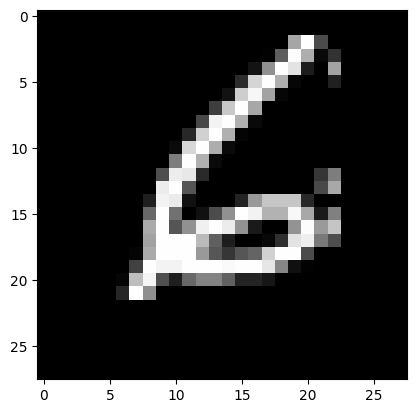

predictions:  [5]
Label:  5


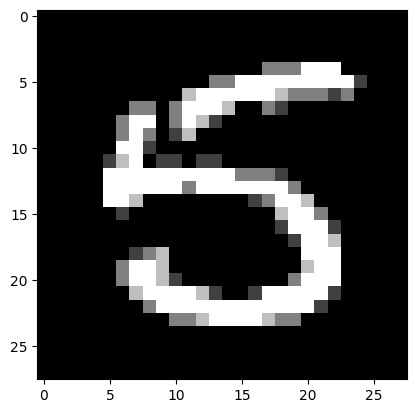

predictions:  [7]
Label:  7


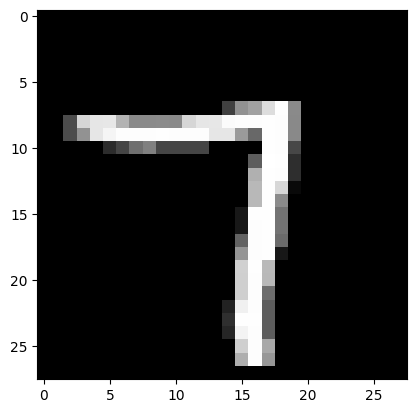

predictions:  [0]
Label:  0


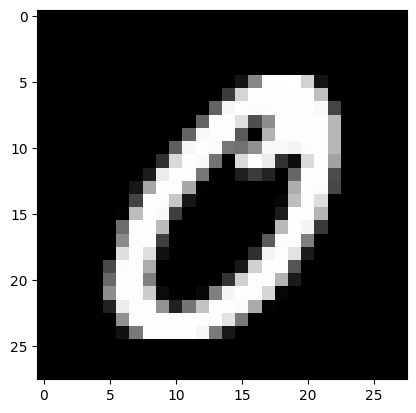

In [11]:
test_pred(0, w1, b1, w2, b2)
test_pred(1, w1, b1, w2, b2)
test_pred(2, w1, b1, w2, b2)
test_pred(3, w1, b1, w2, b2)

In [12]:
val_predictions=make_pred(x_val,w1,b1,w2,b2)
print(get_accuracy(val_predictions,y_val))

[2 2 6 7 3 5 2 1 6 8 4 3 5 0 8 8 1 5 7 6 8 4 8 2 2 3 5 1 2 9 6 6 2 6 7 4 4
 5 3 3 2 2 8 8 1 9 0 9 1 7 0 9 4 9 0 4 3 6 5 6 4 2 2 5 8 0 1 4 0 6 4 9 4 7
 8 1 7 2 0 9 4 6 2 1 8 9 5 6 8 4 6 2 8 5 5 9 7 3 5 3 3 9 9 9 4 9 5 9 2 0 5
 7 1 4 3 0 0 9 0 2 6 1 9 8 5 6 6 2 3 4 2 1 1 8 7 9 8 3 4 4 3 2 7 3 5 4 5 7
 6 9 2 3 5 6 0 3 1 1 9 2 6 5 7 8 4 9 4 8 8 5 7 6 0 9 5 8 1 0 9 1 9 1 2 3 5
 3 2 1 3 2 7 4 3 9 1 1 3 7 1 5 2 7 1 1 7 8 3 6 3 5 5 0 9 5 2 3 2 9 2 0 6 1
 3 9 1 0 2 2 2 3 8 1 2 1 3 9 2 9 5 5 7 4 4 6 9 9 8 3 5 9 2 1 1 4 8 4 3 9 1
 7 9 7 3 3 4 1 5 9 0 6 9 1 0 1 2 7 7 2 0 4 3 3 0 2 1 1 4 9 3 0 4 0 4 0 4 3
 4 7 4 6 9 3 7 0 8 7 7 7 1 2 4 7 4 9 8 2 3 9 2 9 2 1 1 6 9 7 2 7 8 4 7 6 3
 6 7 8 9 1 3 2 9 3 0 6 4 0 4 4 6 0 9 7 9 0 9 1 1 3 4 2 6 8 8 4 6 9 4 1 0 2
 2 0 1 4 4 8 5 9 3 5 0 8 3 5 5 4 6 9 3 3 4 8 0 4 0 6 1 5 5 0 4 4 4 7 7 3 8
 8 1 5 7 2 4 5 1 6 3 9 9 7 6 2 6 0 7 7 7 0 3 4 3 4 6 7 6 8 7 6 0 9 7 9 9 0
 7 6 7 9 3 4 3 6 2 1 0 6 9 5 6 8 1 7 0 0 1 4 2 9 2 8 4 9 8 1 5 7 8 1 8 5 3
 4 7 2 6 0 9 6 0 4 2 4 7 